In [37]:
import numpy as np
import pandas as pd
import mne
import os
from datetime import datetime
from mne.channels import make_standard_montage
from sklearn.decomposition import PCA
import pickle
import matplotlib.pyplot as plt

In [38]:
def add_three_hours(timestamp):
    k = timestamp.split('T')
    k[1]= str(int(k[1][:2])+3)+k[1][2:]
    return 'T'.join(k)

def mp(c):
    """Convert log color markers to valid Plotly colors"""
    if c.strip()=="'blue'":
        return 'blue'
    if c.strip()=="'lightblue'":
        return 'red'
    return 'black'

def eeg_only(df):
    eeg_cols = [col for col in df.columns if (col.startswith('EEG.')) and col not in ['EEG.Counter', 'EEG.RawCq']]
    return df[eeg_cols]

def alt_pipeline(file_path):
    df = pd.read_csv(file_path)
    df.drop(columns=["EEG.Interpolated", "OriginalTimestamp", "EEG.MarkerHardware", "EEG.BatteryPercent", "MOT.CounterMems", "MOT.InterpolatedMems", 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY',
        'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ', "EEG.Battery", "EQ.SampleRateQuality", "PM.Engagement.IsActive", "PM.Excitement.IsActive", "PM.Stress.IsActive", "PM.Relaxation.IsActive", "PM.Interest.IsActive",'MC.Action', 'MC.ActionPower', 'MC.IsActive', 'CQ.AF3', 'CQ.F7', 'CQ.F3', 'CQ.FC5', 'CQ.T7', 'CQ.P7', 'CQ.O1',
        'CQ.O2', 'CQ.P8', 'CQ.T8', 'CQ.FC6', 'CQ.F4', 'CQ.F8', 'CQ.AF4',
        'CQ.Overall', 'EQ.OVERALL', 'EQ.AF3', 'EQ.F7', 'EQ.F3', 'EQ.FC5', 'EQ.T7', 'EQ.P7',
        'EQ.O1', 'EQ.O2', 'EQ.P8', 'EQ.T8', 'EQ.FC6', 'EQ.F4', 'EQ.F8', 'MarkerType', 'MarkerIndex', 'MarkerValueInt',
        'EQ.AF4'], inplace=True, errors='ignore')
    
    try:
        timestamps = pd.to_numeric(df['Timestamp'], errors='coerce')
        timestamps = timestamps[~np.isnan(timestamps)]
        if len(timestamps) > 1:
                sfreq = 1.0 / np.median(np.diff(timestamps))
                if not (10 < sfreq < 1000):
                    print(f"Warning: Calculated sfreq ({sfreq:.2f} Hz) seems unusual. Falling back to 128 Hz.")
                    sfreq = 128.0
        else:
                print("Warning: Not enough valid 'Timestamp' values to calculate sfreq. Falling back to 128 Hz.")
                sfreq = 128.0
    except Exception as e:
        print(f"Warning: Error processing 'Timestamp' column: {e}. Falling back to 128 Hz.")
        sfreq = 128.0
    df.index = df['Timestamp']
    start_timestamp = df['Timestamp'].iloc[0]
    df.drop("Timestamp", axis=1,inplace=True)
    return df, sfreq, start_timestamp

event_id = {
    'covert_speech': 1,
    'overt_speech': 2,
    'fixation': 3,
}

In [39]:

files_256 = [
    "Mariam Alzoubi1748421044458_EPOCX_211983_2025.05.28T11.30.46+03.00.md.pm.bp.mc.fe.csv",
    "Kinda Mashal1748955877058_EPOCX_211983_2025.06.03T16.04.38+03.00.md.pm.bp.mc.fe.csv",
    "Rama Bashar1748353496467_EPOCX_211983_2025.05.27T16.44.57+03.00.md.pm.bp.mc.fe.csv",
    "Malak Tamimi1748951740528_EPOCX_211983_2025.06.03T14.55.41+03.00.md.pm.bp.mc.fe.csv",
    "Mohammad Shahwan1748424849832_EPOCX_211983_2025.05.28T12.34.11+03.00.md.pm.bp.mc.fe.csv",
    "Rama Bashar1748352682130_EPOCX_211983_2025.05.27T16.31.24+03.00.md.pm.bp.mc.fe.csv",
    "mohammad jaradat1750242921892_EPOCX_211983_2025.06.18T13.35.24+03.00.md.pm.bp.mc.fe.csv",
    "Kinda Mashal1748954273361_EPOCX_211983_2025.06.03T15.37.54+03.00.md.pm.bp.mc.fe.csv",
    "Mohammad Shahwan1748426328305_EPOCX_211983_2025.05.28T12.58.49+03.00.md.pm.bp.mc.fe.csv",
    "Kinda Mashal1748955054298_EPOCX_211983_2025.06.03T15.50.55+03.00.md.pm.bp.mc.fe.csv",
    "Mohammad Shahwan1748424068255_EPOCX_211983_2025.05.28T12.21.10+03.00.md.pm.bp.mc.fe.csv",
    "mohammad jaradat1750242146773_EPOCX_211983_2025.06.18T13.22.28+03.00.md.pm.bp.mc.fe.csv",
    "Mariam Alzoubi1748421900422_EPOCX_211983_2025.05.28T11.45.02+03.00.md.pm.bp.mc.fe.csv",
    "Malak Tamimi1748952464968_EPOCX_211983_2025.06.03T15.07.46+03.00.md.pm.bp.mc.fe.csv",
    "Malak Tamimi1748950961776_EPOCX_211983_2025.06.03T14.42.43+03.00.md.pm.bp.mc.fe.csv",
    "Aws Safi1742290353356_EPOCX_211983_2025.03.18T12.32.34+03.00.md.pm.bp.csv",
    "Khaled Abu Qteish1742217278209_EPOCX_211983_2025.03.17T16.14.39+03.00.md.pm.bp.csv",
    "Mohammad Tarshihi1742897131405_EPOCX_211983_2025.03.25T13.05.32+03.00.md.pm.bp.csv",
    "Aws Safi1742289648917_EPOCX_211983_2025.03.18T12.20.50+03.00.md.pm.bp.csv",
    "Aws Safi1742291163364_EPOCX_211983_2025.03.18T12.46.04+03.00.md.pm.bp.csv",
    "Mohammad Tarshihi1742896030991_EPOCX_211983_2025.03.25T12.47.12+03.00.md.pm.bp.csv",
    "Mohammad Tarshihi1742898052037_EPOCX_211983_2025.03.25T13.20.53+03.00.md.pm.bp.csv",
    

]

In [40]:
with open("processed_data_pca.pkl", "rb") as f:
    processed_l = pickle.load(f)

In [69]:
e = processed_l[10]["epochs_cleaned"]

    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF3', 'AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF3', 'AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['F4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch

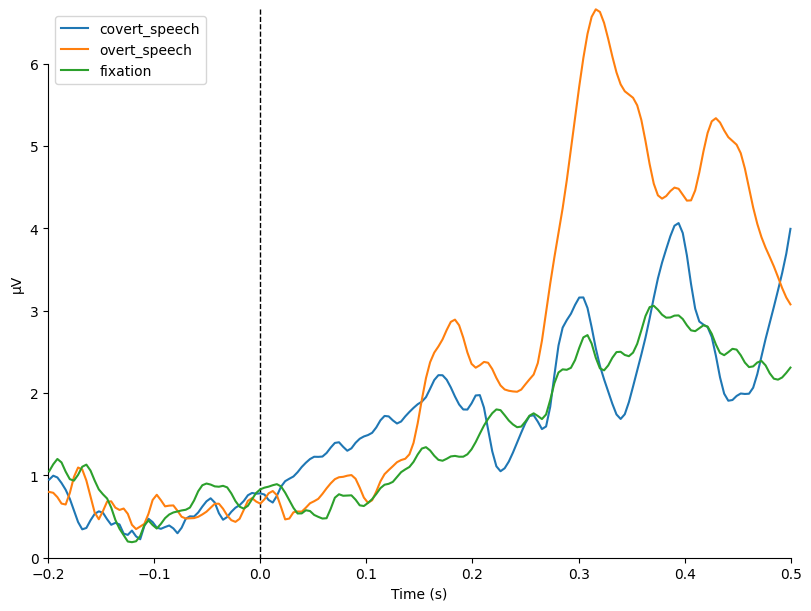

[<Figure size 800x600 with 1 Axes>]

In [70]:
mne.viz.plot_compare_evokeds([e['covert_speech'].average(), e['overt_speech'].average(), e['fixation'].average()])

In [7]:
e

<Epochs | 593 events (good & bad), -0.199 – 0.5 s (baseline -0.199 – 0 s), ~23 KiB, data not loaded,
 'covert_speech': 130
 'overt_speech': 130
 'fixation': 333>

In [10]:
def gfp(data):
    return data.std(axis=0, ddof=0)

In [18]:
X.shape

(2536, 14, 154)

In [9]:
mne.viz.plot_compare_evokeds([e['covert_speech'].average()-e.baseline, e['overt_speech'].average()-e.baseline, e['fixation'].average()-e.baseline])

NameError: name 'e' is not defined

In [ ]:
cov = e["covert_speech"].average().get_data()
ov = e["overt_speech"].average().get_data()
fx = e["fixation"].average().get_data()

In [185]:
e["covert_speech"].get_data().shape

Using data from preloaded Raw for 94 events and 180 original time points ...


(94, 14, 180)

In [105]:
e["covert_speech"].get_data().shape

Using data from preloaded Raw for 94 events and 180 original time points ...


(94, 14, 180)

In [115]:
gfp(cov).shape

(180,)

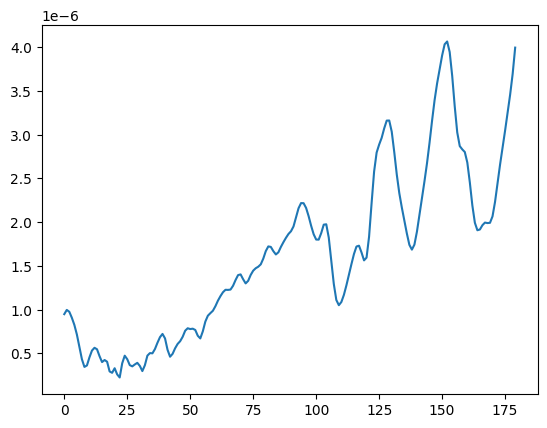

In [121]:
plt.plot(gfp(cov))

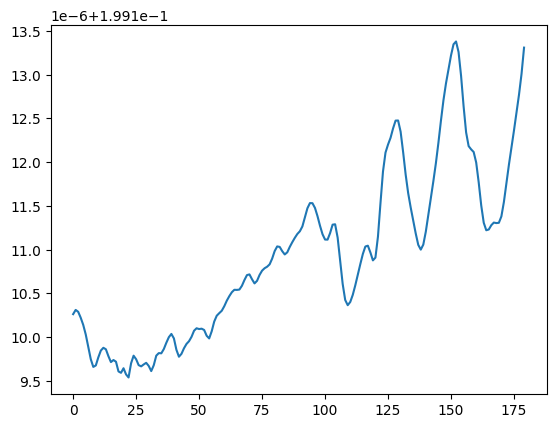

In [127]:
plt.plot(gfp(cov)-e.baseline[0])

In [167]:
e.baseline

(-0.19910931587219238, 0.0)

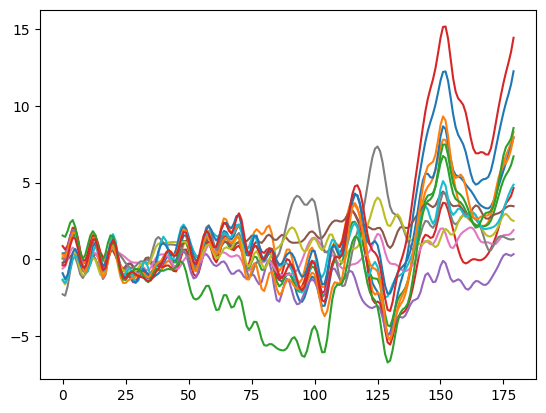

In [184]:
plt.plot((cov * 1e6).T, label='Covert Speech')
# plt.plot((ov * 1e6).T, label='Overt Speech')
# plt.plot((fx * 1e6).T, label='Fixation')
# plt.legend()
plt.show()

In [95]:
print(e.baseline, e['covert_speech'].average().baseline, e['overt_speech'].average().baseline, e['fixation'].average().baseline)

(-0.19910931587219238, 0.0) (-0.19910931587219238, 0.0) (-0.19910931587219238, 0.0) (-0.19910931587219238, 0.0)


In [76]:
e.get_data().shape

Using data from preloaded Raw for 482 events and 180 original time points ...


(482, 14, 180)

In [75]:
X.shape

(526, 14, 154)

In [ ]:
e.get_data()

Using data from preloaded Raw for 482 events and 180 original time points ...


numpy.ndarray

In [59]:
e["covert_speech"]

<Epochs | 130 events (good & bad), -0.199 – 0.5 s (baseline -0.199 – 0 s), ~23 KiB, data not loaded,
 'covert_speech': 130>

In [61]:
X[0].shape

(14, 154)

In [148]:
np.average(zero, axis=0).shape

(14, 307)

In [151]:
X,y = np.load("all_channels_no_pca.npz").values()

In [165]:
zero = X[y==0]
one = X[y==1]
two = X[y==2]
three = X[y==3]

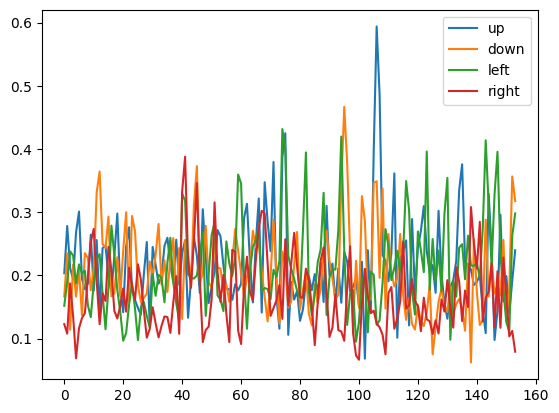

In [166]:
plt.plot(gfp(np.average(zero,axis=0) * 1e6), label = 'up')
plt.plot(gfp(np.average(one,axis=0) * 1e6), label = 'down')
plt.plot(gfp(np.average(two,axis=0) * 1e6), label = 'left')
plt.plot(gfp(np.average(three,axis=0) * 1e6), label = 'right')
plt.legend()
plt.show()

In [162]:
# X,y = np.load("gamma_epochs_no_pca.npz").values()
zero = X[y==0]
one = X[y==1]
two = X[y==2]
three = X[y==3]

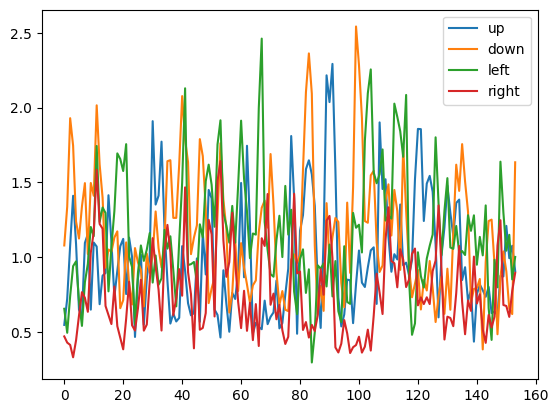

In [163]:
plt.plot(gfp(np.average(zero,axis=0) * 1e6), label = 'up')
plt.plot(gfp(np.average(one,axis=0) * 1e6), label = 'down')
plt.plot(gfp(np.average(two,axis=0) * 1e6), label = 'left')
plt.plot(gfp(np.average(three,axis=0) * 1e6), label = 'right')
plt.legend()
plt.show()

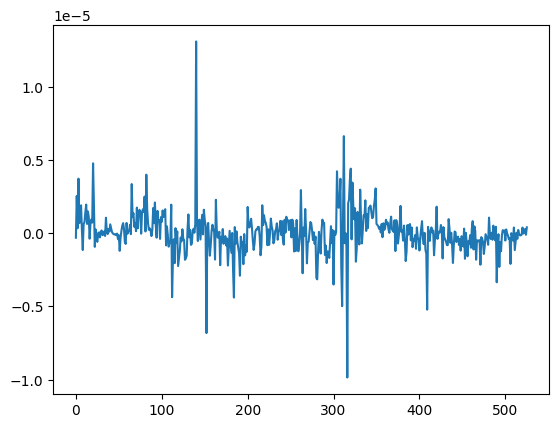

In [38]:
plt.plot(np.average(np.average(X,axis=1), axis=1))

In [44]:
logs_l = []
for l in files_256:
    log_file = os.path.join("data_logs",l.split("1")[0], l.split("1")[0]+"_run"+l[l.find("1"):l.find("_EPOCX")]+".txt")
    logs_l.append(log_file)
    
logs = {}
for log_file in logs_l:
    if not log_file.endswith('.txt'):
        continue
    identifier = log_file.split("_run")[1].split(".")[0]
    try:
        with open(f"{log_file}", "r") as f:
            a = f.readlines()
            if not a:
                print(f"WARNING: Empty log file: {log_file}")
                continue
            logs[identifier] = [
                (datetime.strptime(add_three_hours(line.split(" ")[0]), "[%Y-%m-%dT%H:%M:%S.%fZ]").timestamp(),
                mp(line.split(" ")[-1]),
                " ".join(line.split(" ")[2:]))
                for line in a
                if 'blue' in line or '+' in line
            ]
    except Exception as e:
        print(f"ERROR parsing log file {log_file}: {str(e)}")

In [10]:
processed_l = []
exclude = [
[ 0 ],
[ 0,1,4,12 ],
[ 1,10 ],
[ 7, 9, 11 ],
[ 1,2, 6, 13 ],
[ 1,2,3,13 ],
[ 12 ],
[ 0,3,9 ],
[ 0,1 ],
[ 10 ],
[ 0,2,4,7 ],
[ 0,4,13 ],
[],
[ 6,9,13 ],
[ 0,1,4,7 ],
[2,3],
[0,1,5],
[0],
[0,1,4,9],
[5],
[0],
[0,8]
]
for i,file in enumerate(files_256):
    p, sf, st = alt_pipeline(os.path.join("data", file))
    p = eeg_only(p)
    d = p.values.T
    ch_names = [name.split('.')[1] for name in p.columns.tolist()]
    inf = mne.create_info(ch_names=ch_names, sfreq=sf, ch_types=(['eeg']*len([i for i in p.columns if i.startswith('EEG.')]))+['bio']*len([i for i in p.columns if i.startswith('FE.')]))
    r = mne.io.RawArray(d, inf, verbose=False)
    r._data = r._data - np.mean(r._data, axis=1, keepdims=True)
    mont = make_standard_montage('standard_1020')
    r.set_montage(mont, match_case=False, on_missing='warn')
    
    ev = []
    raw_ind = p.index

    for timestamp, color, description in logs[file.split("_")[0][file.split("_")[0].find("1"):]]:
        sample_idx = np.searchsorted(raw_ind, timestamp)

        if sample_idx >= len(raw_ind) or sample_idx < 0:
            continue
            
        if color == 'blue':
            event_type = event_id['covert_speech']
        elif color == 'red':
            event_type = event_id['overt_speech']
        elif color == 'black':
            event_type = event_id['fixation']
        else:
            continue  
        ev.append([sample_idx, 0, event_type])

    ev = np.array(ev, dtype=int)

    r.filter(1, 64, fir_design="firwin")
    r_d = r.get_data() * 1e-6
    r._data = r_d
    rej = dict(eeg=200e-6)
    ep = mne.Epochs(r, ev, reject=rej, event_id=event_id, picks='eeg', event_repeated='drop')
    ic = mne.preprocessing.ICA(n_components=14, method='picard', random_state=15)
    ic.fit(r)
    print(f"Fitted ICA for {file}")
    # ic.plot_sources(r)
    ic.apply(r, exclude=exclude[i])
    pca = PCA(n_components=14).fit(r.get_data().T)
    pcs = pca.transform(r.get_data().T).T
    epo_clean = mne.Epochs(r, ev, reject=rej, event_id=event_id, picks='eeg', event_repeated='drop')

    processed_l.append({"processed": p, "sfreq": sf, "start_timestamp": st, "raw": r, "events": ev, "epochs": ep, "epochs_cleaned": epo_clean, "pca": pcs})

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 64.00 Hz
- Upper transition bandwidth: 16.00 Hz (-6 dB cutoff frequency: 72.00 Hz)
- Filter length: 847 samples (3.307 s)

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
582 matching events found
Setting baseline interval to [-0.19910931587219238, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Fitting ICA to data using 14 channels (please be patient, this may take a while)
Selecting by number: 14 components


KeyboardInterrupt: 

In [83]:
event_id

{'covert_speech': 1, 'overt_speech': 2, 'fixation': 3}

In [90]:
ev = processed_l[0]["events"]
# get array of events where third column is 1 (covert_speech)
len(ev[ev[:, 2] == 1])

130

In [86]:
ev

array([[    34,      0,      3],
       [    34,      0,      3],
       [   297,      0,      2],
       ...,
       [172319,      0,      1],
       [172710,      0,      3],
       [172711,      0,      3]])

In [ ]:
r._data.shape

(14, 86647)

In [61]:
np.mean(r._data, axis=1).shape

(14,)

In [91]:
X, y = extract_gamma(processed_l[0]["raw"], extract_word_events(logs, identifier=files_256[0].split("_")[0][files_256[0].split("_")[0].find("1"):], words=['up', 'down', 'left', 'right']), start_timestamp=processed_l[0]["start_timestamp"], sfreq=processed_l[0]["sfreq"])
X.shape

['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4'] ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4'] (14, 173221) (14, 173221) defaultdict(<function extract_word_events.<locals>.<lambda> at 0x1098bf380>, {'right': {'covert': [1748421047.392, 1748421171.292, 1748421208.159, 1748421306.276, 1748421327.792, 1748421400.209, 1748421493.194, 1748421565.993, 1748421618.175, 1748421665.226], 'overt': [1748421049.927, 1748421173.842, 1748421210.728, 1748421308.824, 1748421330.347, 1748421402.734, 1748421495.743, 1748421568.57, 1748421620.743, 1748421667.793], 'fixation': [1748421046.366, 1748421048.909, 1748421139.537, 1748421142.093, 1748421144.659, 1748421147.22, 1748421149.77, 1748421152.326, 1748421154.868, 1748421157.426, 1748421160.005, 1748421162.549, 1748421165.107, 1748421167.686, 1748421170.269, 1748421172.81, 1748421175.376, 1748421177.91, 1748421180.472, 1748421181.504, 1748421184.043, 1748421186.61, 174842

(25, 14, 307)

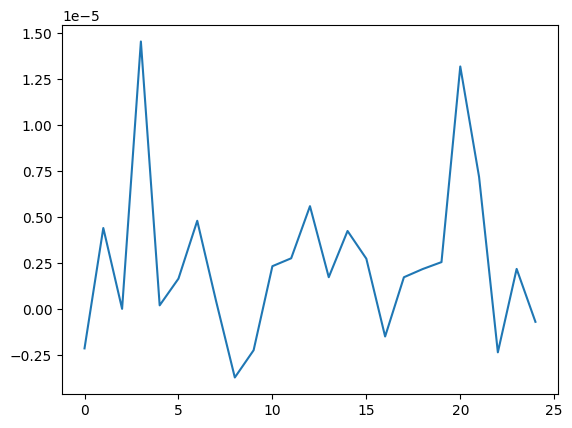

In [93]:
plt.plot(np.average(np.average(X,axis=1), axis=1))

In [ ]:
# with open("processed_data_pca.pkl", "wb") as f:
#     pickle.dump(processed_l, f)

In [41]:
with open("processed_data_pca.pkl", "rb") as f:
    processed_l = pickle.load(f)

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F
from collections import defaultdict
import re

# Different band combinations

In [ ]:
# def extract_word_events(logs, identifier=None, words=('up', 'down', 'left', 'right')):
#     word_events = defaultdict(lambda: {'covert': [], 'overt': [], 'fixation': []})
#     logs_list = logs["1748950961776"] if not identifier else logs[identifier]
#     i = 0
#     while i < len(logs_list):
#         timestamp, color, desc = logs_list[i]
#         match = re.search(r"display to '(\w+)'", desc)
#         if match:
#             word = match.group(1).lower()
#             if word in words:
#                 if color == 'red':
#                     word_events[word]['overt'].append(timestamp)
#                 elif color == 'blue':
#                     word_events[word]['covert'].append(timestamp)
#         elif 'cross' in desc and color == 'black':
#             j = i + 1
#             while j < len(logs_list):
#                 next_timestamp, next_color, next_desc = logs_list[j]
#                 next_match = re.search(r"display to '(\w+)'", next_desc)
#                 if next_match:
#                     next_word = next_match.group(1).lower()
#                     if next_word in words:
#                         word_events[next_word]['fixation'].append(timestamp)
#                         break
#                 j += 1
#         i += 1
#     return word_events

# def extract_gamma(raw, word_events, start_timestamp, tmin=-0.4, tmax=0.8, sfreq=128, second_band=None):
#     bands = {
#         'delta': (0.5, 4),
#         'theta': (4, 8),
#         'alpha': (8, 12),
#         'beta': (12, 30),
#         'gamma': (30, 64)
#     }
#     filtered_raw = raw.filter(bands['gamma'][0], bands['gamma'][1], fir_design='firwin')
#     if second_band:
#         filtered_raw_second = raw.copy().filter(bands[second_band][0], bands[second_band][1], fir_design='firwin')
#     X = []
#     y = []
    
#     label_map = {'up': 0, 'down': 1, 'left': 2, 'right': 3}
#     # label_map = {'up': 0, 'down': 0, 'left': 1, 'right': 1}
#     print(raw.info["ch_names"], filtered_raw.info["ch_names"], raw._data.shape, filtered_raw._data.shape, word_events)
#     for word in ['up', 'down', 'left', 'right']:
#         # for event_type in ['covert', 'overt']:
#         for event_type in ['covert']:
#             event_times = word_events[word][event_type]
#             for t in event_times:
#                 idx = np.searchsorted(filtered_raw.times, t-start_timestamp)
#                 start = int(idx + tmin * sfreq)
#                 end = int(idx + tmax * sfreq)
                
#                 if start >= 0 and end < filtered_raw._data.shape[1]:
#                     epoch_data = filtered_raw._data[:, start:end]
#                     if second_band:
#                         epoch_data_theta = filtered_raw_second._data[:, start:end]
#                         epoch_data = np.vstack((epoch_data, epoch_data_theta))
#                     X.append(epoch_data)
#                     y.append(label_map[word])
#                 else:
#                     print(f"Skipping epoch for {word} at {t} (out of bounds)")
    
#     return np.array(X), np.array(y)

# for band in ['delta', 'theta', 'alpha', 'beta']:

#     # ch_names = [name.split('.')[1] for name in processed_l[0]["processed"].columns.tolist()]
#     # inf = mne.create_info(ch_names=ch_names, sfreq=processed_l[0]["sfreq"], ch_types=(['eeg']*len([i for i in processed_l[0]["processed"].columns if i.startswith('EEG.')]))+['bio']*len([i for i in processed_l[0]["processed"].columns if i.startswith('FE.')]))
#     # raw = mne.io.RawArray(processed_l[0]["pca"], inf, verbose=False)
#     # mont = make_standard_montage('standard_1020')
#     # raw.set_montage(mont, match_case=False, on_missing='warn')
#     # X, y = extract_gamma(raw, extract_word_events(logs, identifier=files_256[0].split("_")[0][files_256[0].split("_")[0].find("1"):], words=['up', 'down', 'left', 'right']), start_timestamp=processed_l[0]["start_timestamp"], sfreq=processed_l[0]["sfreq"], second_band=band)
#     X, y = extract_gamma(processed_l[0]["raw"], extract_word_events(logs, identifier=files_256[0].split("_")[0][files_256[0].split("_")[0].find("1"):], words=['up', 'down', 'left', 'right']), start_timestamp=processed_l[0]["start_timestamp"], sfreq=processed_l[0]["sfreq"], second_band=band)
#     if X.shape[2] > 200:
#         X = X[:, :, ::2]
#     print(X.shape, y.shape)

#     for i, item in enumerate(processed_l[1:]):
#         raw = item["raw"]
#         # ch_names = [name.split('.')[1] for name in item["processed"].columns.tolist()]
#         # inf = mne.create_info(ch_names=ch_names, sfreq=item["sfreq"], ch_types=(['eeg']*len([i for i in item["processed"].columns if i.startswith('EEG.')]))+['bio']*len([i for i in item["processed"].columns if i.startswith('FE.')]))
#         # raw = mne.io.RawArray(item["pca"], inf, verbose=False)
#         # mont = make_standard_montage('standard_1020')
#         # raw.set_montage(mont, match_case=False, on_missing='warn')

#         word_events = extract_word_events(logs, identifier=files_256[i+1].split("_")[0][files_256[i+1].split("_")[0].find("1"):], words=['up', 'down', 'left', 'right'])
#         sfreq = item["sfreq"]
#         X_item, y_item = extract_gamma(raw, word_events, start_timestamp=item["start_timestamp"], sfreq=sfreq, second_band=band)
#         if X_item.shape[2] > 200:
#             X_item = X_item[:, :, ::2]
#         print(X_item.shape, y_item.shape)
#         X = np.concatenate((X, X_item), axis=0)
#         y = np.concatenate((y, y_item), axis=0)

#     np.savez_compressed(f"gamma_{band}_no_pca.npz", X=X, y=y)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 30 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 30.00
- Lower transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 26.25 Hz)
- Upper passband edge: 64.00 Hz
- Upper transition bandwidth: 16.00 Hz (-6 dB cutoff frequency: 72.00 Hz)
- Filter length: 113 samples (0.441 s)

['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4'] ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4'] (14, 173221) (14, 173221) defaultdict(<function extract_word_events.<locals>.<lambda> at 0x17864ff60>, {'right': {'covert': [1748421049.927, 1748421173.842, 1748421210.728, 1748421308.824, 1748421330.347, 1748421402.734, 1748421495.743, 1748421568.57, 174842

# All Channels

In [45]:
# label_map = {'son': 0, 'pear': 1, 'sun': 2, 'sea': 3, 'flower': 4, 'pair': 5, 'see': 6, 'night': 7,
#                 'right': 8, 'knight': 9, 'write': 10, 'flour': 11,
#                 'down': 12, 'smart': 13, 'big': 14,
#                 'left': 15, 'couple': 16, 'quick': 17,
#                 'up': 18, 'clever': 19}
# word_list = ["son", "pear", "sun", "sea", "flower", "pair", "see", "night",
#                 "right", "knight", "write", "flour",
#                 "down", "smart", "big",
#                 "left", "couple", "quick",
#                 "up", "clever"]
label_map = {'up': 0, 'down': 1, 'left': 2, 'right': 3}
word_list = ["up", "down", "left", "right"]

def extract_word_events(logs, identifier=None, words=('up', 'down', 'left', 'right')):
    word_events = defaultdict(lambda: {'covert': [], 'overt': [], 'fixation': []})
    logs_list = logs["1748950961776"] if not identifier else logs[identifier]
    i = 0
    while i < len(logs_list):
        timestamp, color, desc = logs_list[i]
        match = re.search(r"display to '(\w+)'", desc)
        if match:
            word = match.group(1).lower()
            if word in words:
                if color == 'red':
                    word_events[word]['overt'].append(timestamp)
                elif color == 'blue':
                    word_events[word]['covert'].append(timestamp)
        elif 'cross' in desc and color == 'black':
            j = i + 1
            while j < len(logs_list):
                next_timestamp, next_color, next_desc = logs_list[j]
                next_match = re.search(r"display to '(\w+)'", next_desc)
                if next_match:
                    next_word = next_match.group(1).lower()
                    if next_word in words:
                        word_events[next_word]['fixation'].append(timestamp)
                        break
                j += 1
        i += 1
    return word_events

def extract_gamma(raw, word_events, start_timestamp, tmin=-0.4, tmax=0.8, sfreq=128, second_band=None):
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 12),
        'beta': (12, 30),
        'gamma': (30, 64)
    }
    # filtered_raw = raw.copy().filter(bands['gamma'][0], bands['gamma'][1], fir_design='firwin')
    filtered_raw = raw.copy()
    if second_band:
        filtered_raw_second = raw.copy().filter(bands[second_band][0], bands[second_band][1], fir_design='firwin')
    X = []
    y = []
    
    
    # label_map = {'up': 0, 'down': 0, 'left': 1, 'right': 1}
    # print(raw.info["ch_names"], filtered_raw.info["ch_names"], raw._data.shape, filtered_raw._data.shape, word_events)
    for word in word_list:
        # for event_type in ['covert', 'overt']:
        for event_type in ['covert']:
            event_times = word_events[word][event_type]
            for t in event_times:
                idx = np.searchsorted(filtered_raw.times, t-start_timestamp)
                start = int(idx + tmin * sfreq)
                end = int(idx + tmax * sfreq)
                
                if start >= 0 and end < filtered_raw._data.shape[1]:
                    epoch_data = filtered_raw._data[:, start:end]
                    if second_band:
                        epoch_data_theta = filtered_raw_second._data[:, start:end]
                        epoch_data = np.vstack((epoch_data, epoch_data_theta))
                    X.append(epoch_data)
                    y.append(label_map[word])
                else:
                    print(f"Skipping epoch for {word} at {t} (out of bounds)")
    
    return np.array(X), np.array(y)


# ch_names = [name.split('.')[1] for name in processed_l[0]["processed"].columns.tolist()]
# inf = mne.create_info(ch_names=ch_names, sfreq=processed_l[0]["sfreq"], ch_types=(['eeg']*len([i for i in processed_l[0]["processed"].columns if i.startswith('EEG.')]))+['bio']*len([i for i in processed_l[0]["processed"].columns if i.startswith('FE.')]))
# raw = mne.io.RawArray(processed_l[0]["pca"], inf, verbose=False)
# mont = make_standard_montage('standard_1020')
# raw.set_montage(mont, match_case=False, on_missing='warn')
# X, y = extract_gamma(raw, extract_word_events(logs, identifier=files_256[0].split("_")[0][files_256[0].split("_")[0].find("1"):], words=['up', 'down', 'left', 'right']), start_timestamp=processed_l[0]["start_timestamp"], sfreq=processed_l[0]["sfreq"])
X, y = extract_gamma(processed_l[0]["raw"], extract_word_events(logs, identifier=files_256[0].split("_")[0][files_256[0].split("_")[0].find("1"):], words=word_list), start_timestamp=processed_l[0]["start_timestamp"], sfreq=processed_l[0]["sfreq"])
if X.shape[2] > 200:
    X = X[:, :, ::2]
# print(X.shape, y.shape)

for i, item in enumerate(processed_l[1:]):
    raw = item["raw"]
    # ch_names = [name.split('.')[1] for name in item["processed"].columns.tolist()]
    # inf = mne.create_info(ch_names=ch_names, sfreq=item["sfreq"], ch_types=(['eeg']*len([i for i in item["processed"].columns if i.startswith('EEG.')]))+['bio']*len([i for i in item["processed"].columns if i.startswith('FE.')]))
    # raw = mne.io.RawArray(item["pca"], inf, verbose=False)
    # mont = make_standard_montage('standard_1020')
    # raw.set_montage(mont, match_case=False, on_missing='warn')

    word_events = extract_word_events(logs, identifier=files_256[i+1].split("_")[0][files_256[i+1].split("_")[0].find("1"):], words=word_list)
    sfreq = item["sfreq"]
    X_item, y_item = extract_gamma(raw, word_events, start_timestamp=item["start_timestamp"], sfreq=sfreq)
    if X_item.shape[2] > 200:
        X_item = X_item[:, :, ::2]
    # print(X_item.shape, y_item.shape)
    X = np.concatenate((X, X_item), axis=0)
    y = np.concatenate((y, y_item), axis=0)

reverse_label_map = {v: k for k, v in label_map.items()}


Skipping epoch for up at 1742897264.909 (out of bounds)
Skipping epoch for up at 1742897379.526 (out of bounds)
Skipping epoch for up at 1742897483.88 (out of bounds)
Skipping epoch for up at 1742897644.576 (out of bounds)
Skipping epoch for up at 1742897794.985 (out of bounds)
Skipping epoch for down at 1742897229.265 (out of bounds)
Skipping epoch for down at 1742897343.721 (out of bounds)
Skipping epoch for down at 1742897468.576 (out of bounds)
Skipping epoch for down at 1742897634.342 (out of bounds)
Skipping epoch for down at 1742897754.092 (out of bounds)
Skipping epoch for left at 1742897234.325 (out of bounds)
Skipping epoch for left at 1742897359.076 (out of bounds)
Skipping epoch for left at 1742897478.792 (out of bounds)
Skipping epoch for left at 1742897670.059 (out of bounds)
Skipping epoch for left at 1742897738.748 (out of bounds)
Skipping epoch for right at 1742897244.539 (out of bounds)
Skipping epoch for right at 1742897301.759 (out of bounds)
Skipping epoch for righ

In [46]:
X.shape

(526, 14, 154)

In [42]:
X_all,y_all = np.load("gamma_epochs_no_pca.npz").values()

In [90]:
processed_l[10].keys()

dict_keys(['processed', 'sfreq', 'start_timestamp', 'raw', 'events', 'epochs', 'epochs_cleaned', 'pca'])

0


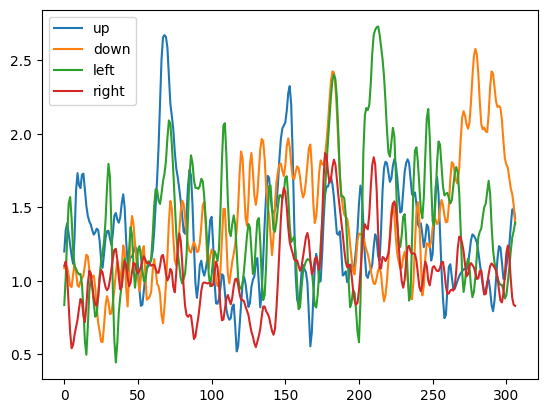

In [89]:
# reverse_map = {v:k for k, v in {'up': 0, 'down': 1, 'left': 2, 'right': 3}.items()}
print(label_map['up'])
up_epochs = X[y==label_map['up']]
down_epochs = X[y==label_map['down']]
left_epochs = X[y==label_map['left']]
right_epochs = X[y==label_map['right']]

plt.plot(gfp(np.average(up_epochs, axis=0))*1e6, label = 'up')
plt.plot(gfp(np.average(down_epochs, axis=0))*1e6, label = 'down')
plt.plot(gfp(np.average(left_epochs, axis=0))*1e6, label = 'left')
plt.plot(gfp(np.average(right_epochs, axis=0))*1e6, label = 'right')
plt.legend()
plt.show()

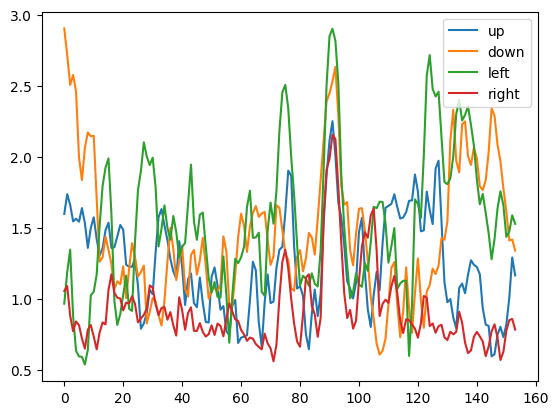

In [63]:
# reverse_map = {v:k for k, v in {'up': 0, 'down': 1, 'left': 2, 'right': 3}.items()}

up_epochs = X[y==label_map['up']]
down_epochs = X[y==label_map['down']]
left_epochs = X[y==label_map['left']]
right_epochs = X[y==label_map['right']]

plt.plot(gfp(np.average(up_epochs, axis=0))*1e6, label = 'up')
plt.plot(gfp(np.average(down_epochs, axis=0))*1e6, label = 'down')
plt.plot(gfp(np.average(left_epochs, axis=0))*1e6, label = 'left')
plt.plot(gfp(np.average(right_epochs, axis=0))*1e6, label = 'right')
plt.legend()
plt.show()

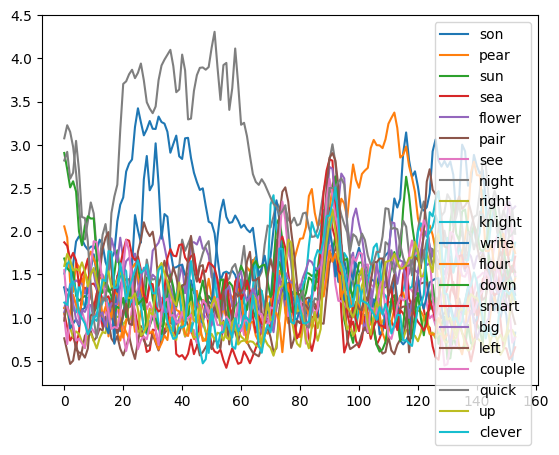

In [34]:
for word in ['son', 'pear', 'sun', 'sea', 'flower', 'pair', 'see', 'night',
                'right', 'knight', 'write', 'flour',
                'down', 'smart', 'big',
                'left', 'couple', 'quick',
                'up', 'clever']:
    word_epochs = X[y==label_map[word]]
    plt.plot(gfp(np.average(word_epochs, axis=0))*1e6, label = word)
plt.legend()
plt.show()

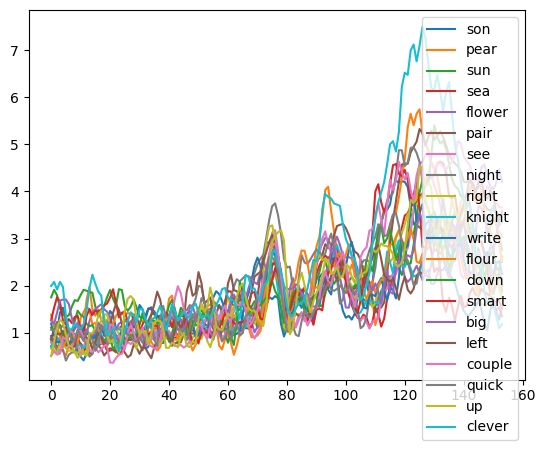

In [26]:
for word in ['son', 'pear', 'sun', 'sea', 'flower', 'pair', 'see', 'night',
                'right', 'knight', 'write', 'flour',
                'down', 'smart', 'big',
                'left', 'couple', 'quick',
                'up', 'clever']:
    word_epochs = X[y==label_map[word]]
    plt.plot(gfp(np.average(word_epochs, axis=0))*1e6, label = word)
plt.legend()
plt.show()

In [127]:
for x in X:
    if not (np.ptp(x, axis=1)<200e-6).all:
        print("Found low amplitude epoch")

In [117]:
X_tr = X*1e6

In [126]:
not np.array([True,False,True]).all()

True

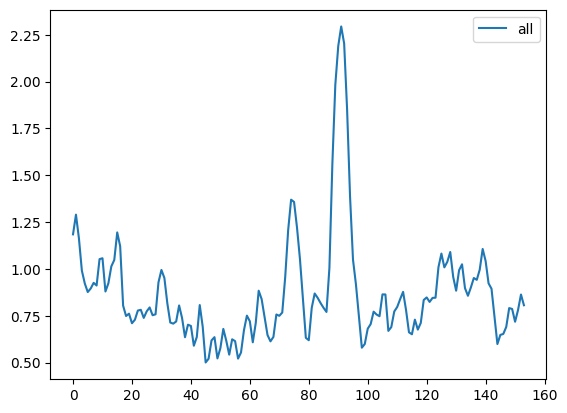

In [150]:
plt.plot(gfp(np.average(X, axis=0))*1e6, label = 'all')
plt.legend()
plt.show()

In [134]:
np.ptp(e2["covert_speech"].get_data(),axis=2)

Using data from preloaded Raw for 130 events and 180 original time points ...
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF3', 'AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF3', 'AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['F4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on 

array([[1.20237583e-04, 9.34283788e-05, 7.08203694e-05, ...,
        8.94099876e-05, 1.37730760e-04, 1.33362566e-04],
       [1.58708368e-04, 1.30377063e-04, 9.67393385e-05, ...,
        1.13711717e-04, 1.44457019e-04, 1.77043187e-04],
       [3.83477733e-05, 7.05242860e-05, 4.73479338e-05, ...,
        6.99652210e-05, 1.97678928e-04, 4.75315425e-05],
       ...,
       [1.64785515e-04, 1.32857182e-04, 1.14819456e-04, ...,
        1.63939154e-04, 1.76862847e-04, 1.94390325e-04],
       [7.33824063e-05, 8.07073901e-05, 6.06844381e-05, ...,
        7.77992871e-05, 9.48195358e-05, 8.51202760e-05],
       [8.21481440e-05, 8.13822704e-05, 7.43729772e-05, ...,
        1.01143346e-04, 9.26753486e-05, 9.55760541e-05]])

In [145]:
np.ptp(X,axis=2)

array([[8.79587076e-05, 4.63628989e-05, 5.51241800e-05, ...,
        9.25670233e-05, 4.99816522e-05, 6.81235068e-05],
       [8.02007214e-05, 5.72261361e-05, 5.51925805e-05, ...,
        8.06173149e-05, 5.06575725e-05, 6.21933391e-05],
       [7.85171529e-05, 5.32716028e-05, 5.93810494e-05, ...,
        8.53924748e-05, 4.17353278e-05, 8.73917604e-05],
       ...,
       [4.25783525e-05, 5.51710250e-05, 3.74437771e-05, ...,
        3.87772340e-05, 5.43357378e-05, 4.83079468e-05],
       [6.23326917e-05, 5.91620086e-05, 5.62058077e-05, ...,
        6.57669353e-05, 6.75603832e-05, 6.66005799e-05],
       [4.15094147e-05, 5.67686675e-05, 4.32804171e-05, ...,
        4.40975142e-05, 5.73606045e-05, 5.13185636e-05]])

In [142]:
1.20237583e-04

0.000120237583

In [136]:
200e-6

0.0002

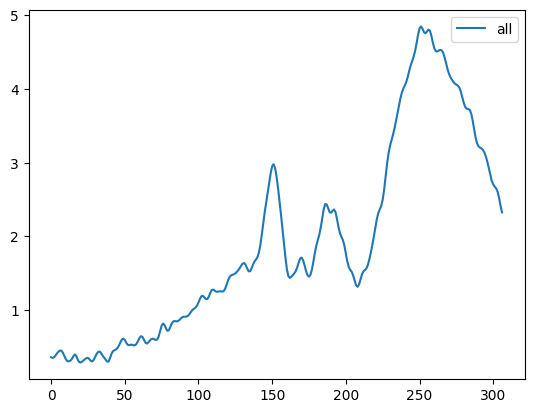

In [100]:
plt.plot(gfp(np.average(X, axis=0))*1e6, label = 'all')
plt.legend()
plt.show()

    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF3', 'AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF3', 'AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['F4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch

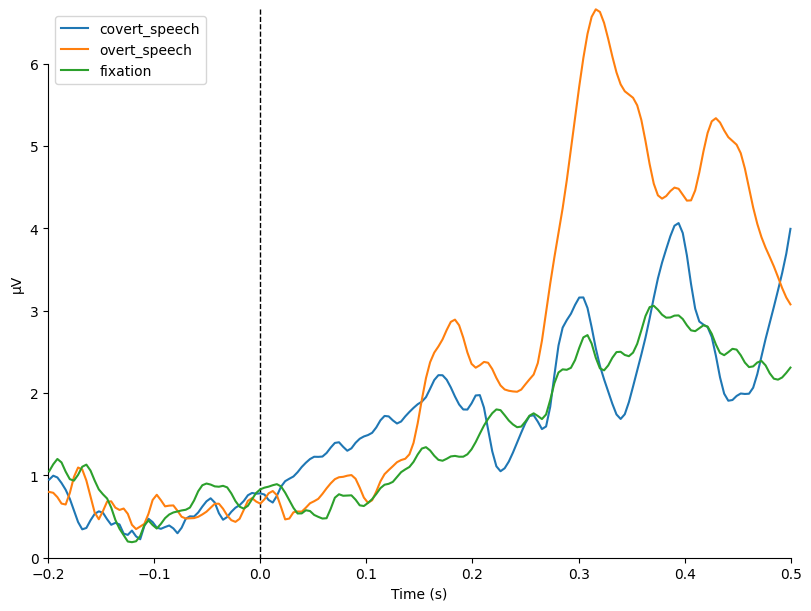

[<Figure size 800x600 with 1 Axes>]

In [85]:
e2 = processed_l[10]["epochs_cleaned"]
mne.viz.plot_compare_evokeds([e2['covert_speech'].average(), e2['overt_speech'].average(), e2['fixation'].average()])

In [77]:
def augment_with_noise(X, y, n_augment=2, noise_level=0.05):
    X_aug = []
    y_aug = []
    
    for i in range(len(X)):
        X_aug.append(X[i])
        y_aug.append(y[i])
        
        for _ in range(n_augment):
            baseline = np.mean(np.abs(X[i]))
            noise = np.random.normal(0, baseline * noise_level, X[i].shape)
            X_aug.append(X[i] + noise)
            y_aug.append(y[i])
    
    return np.array(X_aug), np.array(y_aug)

In [78]:
X, y = augment_with_noise(X, y, n_augment=1, noise_level=0.05)
print(f"Augmented shape: {X.shape}, {y.shape}")

Augmented shape: (1052, 14, 154), (1052,)


In [ ]:
np.savez_compressed("gamma_delta_no_pca.npz", X=X, y=y)

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1)).reshape(X_test.shape)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

In [92]:
class CNN_LSTM_Classifier(nn.Module):
    def __init__(self, n_channels, n_timepoints, n_classes=4):
        super(CNN_LSTM_Classifier, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=n_channels, out_channels=28, groups=n_channels, kernel_size=16, padding='valid')
        self.conv2 = nn.Conv1d(in_channels=28, out_channels=56, groups=28, kernel_size=32, padding='valid')
        self.conv3 = nn.Conv1d(in_channels=56, out_channels=128, groups=1, kernel_size=32, padding='valid')

        self.pool = nn.AvgPool1d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.3)
        
        # self.lstm = nn.LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3)
        # self.dropout2 = nn.Dropout(0.5)
        
        self.classifier = nn.Linear(128, n_classes)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        x = F.relu(self.conv3(x))
        # x = self.pool(x)
        
        x = self.dropout1(x)
        
        # x = x.transpose(1, 2)
        
        # lstm_out, (h_n, c_n) = self.lstm(x)
        
        # x = lstm_out[:, -1, :]
        # flatten to go to linear layer
        x = x.mean(dim=2)
        # x = self.dropout2(x)
        x = self.classifier(x)
        
        return x

n_channels = X_train_tensor.shape[1]
n_timepoints = X_train_tensor.shape[2]
n_classes = 4

model = CNN_LSTM_Classifier(n_channels, n_timepoints, n_classes)
print(model)

CNN_LSTM_Classifier(
  (conv1): Conv1d(14, 28, kernel_size=(16,), stride=(1,), padding=valid, groups=14)
  (conv2): Conv1d(28, 56, kernel_size=(32,), stride=(1,), padding=valid, groups=28)
  (conv3): Conv1d(56, 128, kernel_size=(32,), stride=(1,), padding=valid)
  (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
  (dropout1): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=4, bias=True)
)


In [93]:
device = torch.device('cpu')
print(f"Using device: {device}")

X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Using device: cpu


In [94]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)
    
    return total_loss / len(train_loader), 100. * correct / total

def test_epoch(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            all_preds.extend(pred.cpu().numpy().flatten())
            all_targets.extend(target.cpu().numpy())
    
    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    
    return test_loss, accuracy, all_preds, all_targets

num_epochs = 100
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = test_epoch(model, test_loader, criterion, device)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
            f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

Epoch   0: Train Loss: 1.3631, Train Acc: 37.67%, Test Loss: 1.3361, Test Acc: 40.00%
Epoch  10: Train Loss: 1.2846, Train Acc: 39.67%, Test Loss: 1.3900, Test Acc: 40.00%
Epoch  20: Train Loss: 1.2137, Train Acc: 43.33%, Test Loss: 1.4391, Test Acc: 37.33%


KeyboardInterrupt: 


FINAL RESULTS - CNN-LSTM Directional Movement Classifier
Final Test Accuracy: 26.42%

Classification Report:
              precision    recall  f1-score   support

          up       0.23      0.24      0.23        21
        down       0.33      0.24      0.28        21
        left       0.05      0.05      0.05        21
       right       0.34      0.40      0.37        43

    accuracy                           0.26       106
   macro avg       0.24      0.23      0.23       106
weighted avg       0.26      0.26      0.26       106


Confusion Matrix:
[[ 5  1  8  7]
 [ 4  5  0 12]
 [ 3  3  1 14]
 [10  6 10 17]]


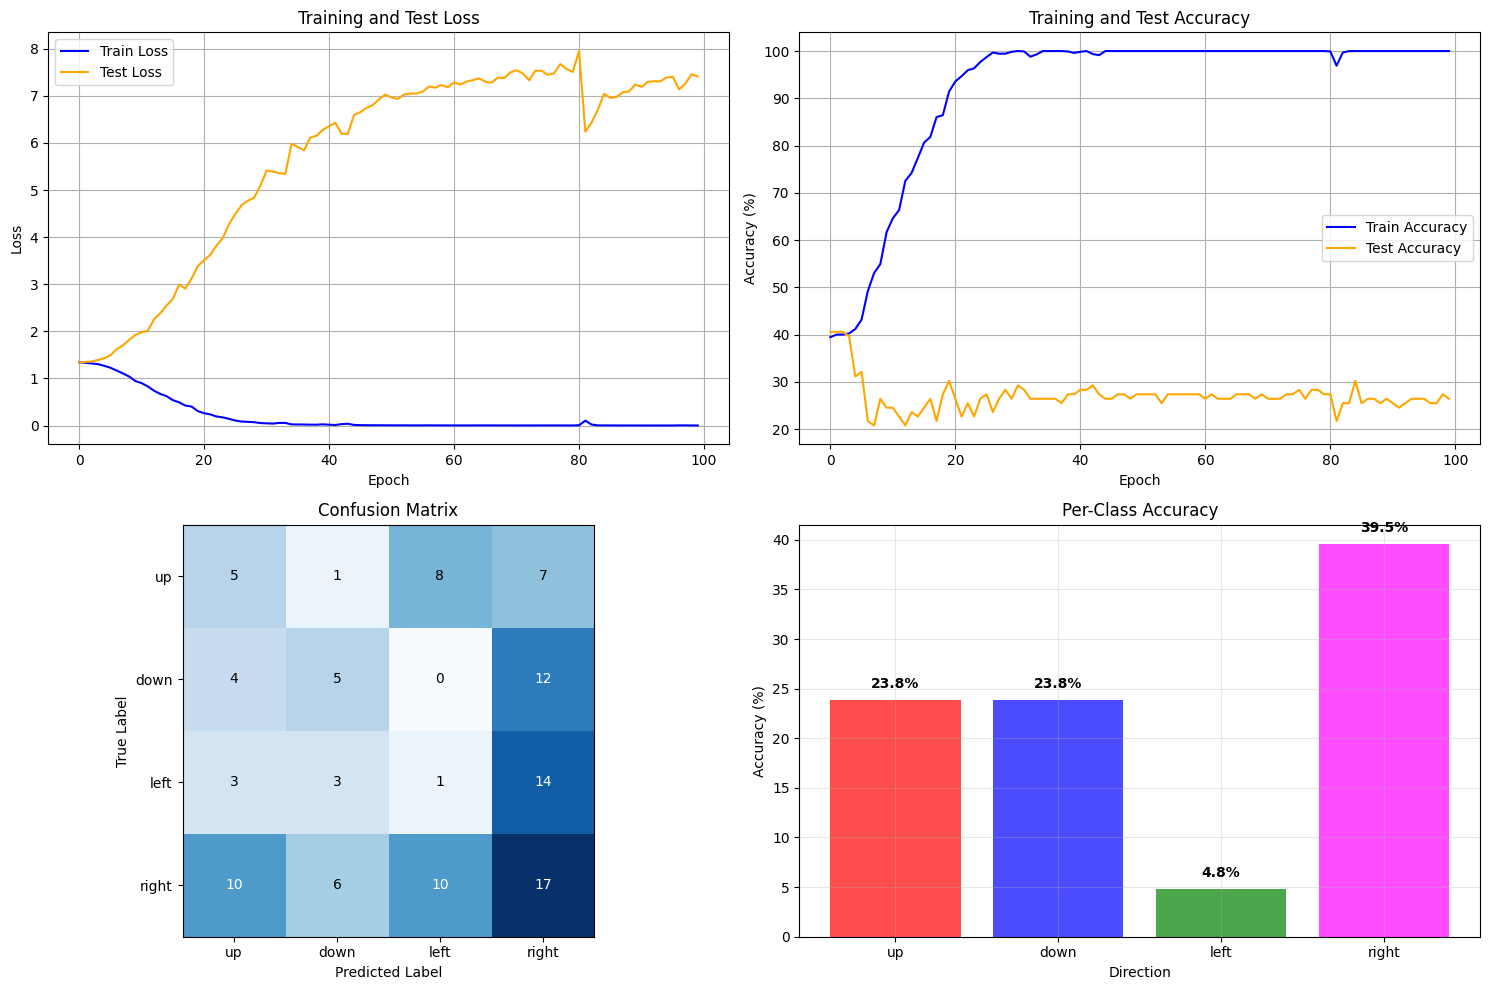


Per-class accuracy:
  UP: 23.8%
  DOWN: 23.8%
  LEFT: 4.8%
  RIGHT: 39.5%

Model Summary:
  - Input: 14 EEG channels, 154 time points
  - Gamma frequency band: 30-100 Hz
  - Architecture: 1D CNN + LSTM
  - Parameters: 232,344
  - Training epochs: 100
  - Final accuracy: 26.42%


In [59]:
_, final_test_acc, test_preds, test_targets = test_epoch(model2, test_loader, criterion, device)

print(f"\n{'='*60}")
print(f"FINAL RESULTS - CNN-LSTM Directional Movement Classifier")
print(f"{'='*60}")
print(f"Final Test Accuracy: {final_test_acc:.2f}%")

class_names = ['up', 'down', 'left', 'right']
print(f"\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=class_names))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(test_targets, test_preds)
print(cm)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].plot(train_losses, label='Train Loss', color='blue')
axes[0,0].plot(test_losses, label='Test Loss', color='orange')
axes[0,0].set_title('Training and Test Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(train_accuracies, label='Train Accuracy', color='blue')
axes[0,1].plot(test_accuracies, label='Test Accuracy', color='orange')
axes[0,1].set_title('Training and Test Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].legend()
axes[0,1].grid(True)

im = axes[1,0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[1,0].set_title('Confusion Matrix')
tick_marks = np.arange(len(class_names))
axes[1,0].set_xticks(tick_marks)
axes[1,0].set_xticklabels(class_names)
axes[1,0].set_yticks(tick_marks)
axes[1,0].set_yticklabels(class_names)
axes[1,0].set_ylabel('True Label')
axes[1,0].set_xlabel('Predicted Label')

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    axes[1,0].text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100
colors = ['red', 'blue', 'green', 'magenta']
bars = axes[1,1].bar(class_names, class_accuracy, color=colors, alpha=0.7)
axes[1,1].set_title('Per-Class Accuracy')
axes[1,1].set_xlabel('Direction')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].grid(True, alpha=0.3)

for i, (bar, acc) in enumerate(zip(bars, class_accuracy)):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nPer-class accuracy:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name.upper()}: {class_accuracy[i]:.1f}%")

print(f"\nModel Summary:")
print(f"  - Input: {n_channels} EEG channels, {n_timepoints} time points")
print(f"  - Gamma frequency band: 30-100 Hz")
print(f"  - Architecture: 1D CNN + LSTM")
print(f"  - Parameters: {sum(p.numel() for p in model2.parameters()):,}")
print(f"  - Training epochs: {num_epochs}")
print(f"  - Final accuracy: {final_test_acc:.2f}%")

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1)).reshape(X_test.shape)
X_train_scaled, y_train_scaled = augment_with_noise(X_train_scaled, y_train, n_augment=2, noise_level=0.05)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train_scaled)
y_test_tensor = torch.LongTensor(y_test)

In [48]:
model2 = CNN_LSTM_Classifier(n_channels, n_timepoints, n_classes)

In [55]:


device = torch.device('cpu')
print(f"Using device: {device}")

X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Using device: cpu


In [57]:
num_epochs = 100
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model2, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = test_epoch(model2, test_loader, criterion, device)

    scheduler.step()
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
            f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

Epoch   0: Train Loss: 1.3423, Train Acc: 39.44%, Test Loss: 1.3391, Test Acc: 40.57%
Epoch  10: Train Loss: 0.9019, Train Acc: 64.60%, Test Loss: 1.9812, Test Acc: 24.53%
Epoch  20: Train Loss: 0.2630, Train Acc: 93.57%, Test Loss: 3.5092, Test Acc: 26.42%
Epoch  30: Train Loss: 0.0481, Train Acc: 100.00%, Test Loss: 5.4116, Test Acc: 29.25%
Epoch  40: Train Loss: 0.0196, Train Acc: 99.84%, Test Loss: 6.3555, Test Acc: 28.30%
Epoch  50: Train Loss: 0.0064, Train Acc: 100.00%, Test Loss: 6.9644, Test Acc: 27.36%
Epoch  60: Train Loss: 0.0042, Train Acc: 100.00%, Test Loss: 7.2836, Test Acc: 26.42%
Epoch  70: Train Loss: 0.0036, Train Acc: 100.00%, Test Loss: 7.5432, Test Acc: 26.42%
Epoch  80: Train Loss: 0.0084, Train Acc: 99.92%, Test Loss: 7.9490, Test Acc: 27.36%
Epoch  90: Train Loss: 0.0033, Train Acc: 100.00%, Test Loss: 7.1905, Test Acc: 25.47%
Epoch  99: Train Loss: 0.0033, Train Acc: 100.00%, Test Loss: 7.4099, Test Acc: 26.42%


# Experiments with feature selection from the recommended paper

In [27]:
from nitime import utils
from nitime import algorithms as alg
from nitime.timeseries import TimeSeries
from nitime.viz import plot_tseries
import csv
import pywt
import scipy.stats as sp
from spectrum import *
from os import listdir
from os.path import isfile, join
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd

In [7]:
t=False

In [8]:
X,y = np.load("unfiltered_covert_pca.npz").values()

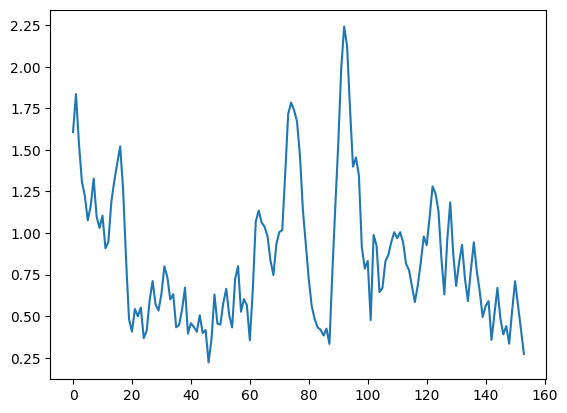

In [11]:
plt.plot(gfp(np.average(X, axis=0))*1e6)

In [12]:
def hjorth(input):
    realinput = input
    hjorth_activity = np.zeros(len(realinput))
    hjorth_mobility = np.zeros(len(realinput))
    hjorth_diffmobility = np.zeros(len(realinput))
    hjorth_complexity = np.zeros(len(realinput))
    diff_input = np.diff(realinput)
    diff_diffinput = np.diff(diff_input)
    k = 0
    for j in realinput:
        hjorth_activity[k] = np.var(j)
        hjorth_mobility[k] = np.sqrt(np.var(diff_input[k])/hjorth_activity[k])
        hjorth_diffmobility[k] = np.sqrt(np.var(diff_diffinput[k])/np.var(diff_input[k]))
        hjorth_complexity[k] = hjorth_diffmobility[k]/hjorth_mobility[k]
        k = k+1
    return hjorth_activity, hjorth_mobility, hjorth_complexity

In [13]:
Activity,Mobility,Complexity = [],[],[]
if t:
    for i in range(X.shape[0]):
        a,m,c = hjorth(X[i].T)
        Activity.append(a)
        Mobility.append(m)
        Complexity.append(c)
else:
    for i in range(X.shape[0]):
        a,m,c = hjorth(X[i])
        Activity.append(a)
        Mobility.append(m)
        Complexity.append(c)

In [15]:
def my_kurtosis(a):
    b = a # Extracting the data from the 14 channels
    output = np.zeros(len(b)) # Initializing the output array with zeros (length = 14)
    k = 0; # For counting the current row no.
    for i in b:
        mean_i = np.mean(i) # Saving the mean of array i
        std_i = np.std(i) # Saving the standard deviation of array i
        t = 0.0
        for j in i:
            t += (pow((j-mean_i)/std_i,4)-3)
        kurtosis_i = t/len(i) # Formula: (1/N)*(summation(x_i-mean)/standard_deviation)^4-3
        output[k] = kurtosis_i # Saving the kurtosis in the array created
        k +=1 # Updating the current row no.
    return output

##----------------------------------------- End Kurtosis Function ----------------------------##


##------------------------------------- Begin 2ndDiffMean(Absolute difference) Function ------##
##-------------------------- [ Input: 2D array (row: Channels, column: Data)] --------------- ##
##-------------------  -- [ Output: 1D array (2ndDiffMean values for each channel)] ----------##

def secDiffMean(a):
    b = a # Extracting the data of the 14 channels
    output = np.zeros(len(b)) # Initializing the output array with zeros (length = 14)
    temp1 = np.zeros(len(b[0])-1) # To store the 1st Diffs
    k = 0; # For counting the current row no.
    for i in b:
        t = 0.0
        for j in range(len(i)-1):
            temp1[j] = abs(i[j+1]-i[j]) # Obtaining the 1st Diffs
        for j in range(len(i)-2):
            t += abs(temp1[j+1]-temp1[j]) # Summing the 2nd Diffs
        output[k] = t/(len(i)-2) # Calculating the mean of the 2nd Diffs
        k +=1 # Updating the current row no.
    return output

##------------------------------------- End 2ndDiffMean Function----- -------------------------##


##------------------------------------- Begin 2ndDiffMax Function(Absolute difference) --------##
##-------------------------- [ Input: 2D array (row: Channels, column: Data)] -----------------##
##--------------------- [ Output: 1D array (2ndDiffMax values for each channel)] --------------##

def secDiffMax(a):
    b = a # Extracting the data from the 14 channels
    output = np.zeros(len(b)) # Initializing the output array with zeros (length = 14)
    temp1 = np.zeros(len(b[0])-1) # To store the 1st Diffs
    k = 0; # For counting the current row no.
    t = 0.0
    for i in b:
        for j in range(len(i)-1):
            temp1[j] = abs(i[j+1]-i[j]) # Obtaining the 1st Diffs
        t = temp1[1] - temp1[0]
        for j in range(len(i)-2):
            if abs(temp1[j+1]-temp1[j]) > t :
                t = temp1[j+1]-temp1[j] # Comparing current Diff with the last updated Diff Max

        output[k] = t # Storing the 2nd Diff Max for channel k
        k +=1 # Updating the current row no.
    return output



def wrapper1(a):
    kurtosis =  my_kurtosis(a)
    sec_diff_mean = secDiffMean(a)
    sec_diff_max  = secDiffMax(a)
    return kurtosis,sec_diff_mean,sec_diff_max

In [16]:
Kurtosis,Second_Difference_Mean, Second_Difference_Max = [],[],[]
if t:
    for i in range(X.shape[0]):
        k,sdm,sdmax = wrapper1(X[i].T)
        Kurtosis.append(k)
        Second_Difference_Mean.append(sdm)
        Second_Difference_Max.append(sdmax)
else:
    for i in range(X.shape[0]):
        k,sdm,sdmax = wrapper1(X[i])
        Kurtosis.append(k)
        Second_Difference_Mean.append(sdm)
        Second_Difference_Max.append(sdmax)

In [17]:
def coeff_var(a):
    b = a #Extracting the data from the 14 channels
    output = np.zeros(len(b)) #Initializing the output array with zeros
    k = 0; #For counting the current row no.
    for i in b:
        mean_i = np.mean(i) #Saving the mean of array i
        std_i = np.std(i) #Saving the standard deviation of array i
        output[k] = std_i/mean_i #computing coefficient of variation
        k=k+1
    return output

In [18]:
Coeffiecient_of_Variation = []
if t:
    for i in range(X.shape[0]):
        cv = coeff_var(X[i].T)
        Coeffiecient_of_Variation.append(cv)
else:
    for i in range(X.shape[0]):
        cv = coeff_var(X[i])
        Coeffiecient_of_Variation.append(cv)

In [19]:
def skewness(arr):
    data = arr 
    skew_array = np.zeros(len(data)) #Initialinling the array as all 0s
    index = 0; #current cell position in the output array
   
    for i in data:
        skew_array[index]=sp.stats.skew(i,axis=0,bias=True)
        index+=1 #updating the cell position
    return skew_array


def first_diff_mean(arr):
    data = arr 
    diff_mean_array = np.zeros(len(data)) #Initialinling the array as all 0s
    index = 0; #current cell position in the output array
   
    for i in data:
        sum=0.0#initializing the sum at the start of each iteration
        for j in range(len(i)-1):
            sum += abs(i[j+1]-i[j]) # Obtaining the 1st Diffs
           
        diff_mean_array[index]=sum/(len(i)-1)
        index+=1 #updating the cell position
    return diff_mean_array


def first_diff_max(arr):
    data = arr 
    diff_max_array = np.zeros(len(data)) #Initialinling the array as all 0s
    first_diff = np.zeros(len(data[0])-1)#Initialinling the array as all 0s 
    index = 0; #current cell position in the output array
   
    for i in data:
        max=0.0#initializing at the start of each iteration
        for j in range(len(i)-1):
            first_diff[j] = abs(i[j+1]-i[j]) # Obtaining the 1st Diffs
            if first_diff[j]>max: 
                max=first_diff[j] # finding the maximum of the first differences
        diff_max_array[index]=max
        index+=1 #updating the cell position
    return diff_max_array


def wrapper2(arr):
    skew   = skewness(arr)
    fdmean = first_diff_mean(arr)
    fdmax  = first_diff_max(arr)
    return skew,fdmean,fdmax

In [20]:
Skewness,First_Difference_Mean,First_Difference_Max = [],[],[]
if t:
    for i in range(X.shape[0]):
        s,fdm,fdmx = wrapper2(X[i].T)
        Skewness.append(s)
        First_Difference_Mean.append(fdm)
        First_Difference_Max.append(fdmx)
else:
    for i in range(X.shape[0]):
        s,fdm,fdmx = wrapper2(X[i])
        Skewness.append(s)
        First_Difference_Mean.append(fdm)
        First_Difference_Max.append(fdmx)

/var/folders/h2/p1hlwwls3jz9yndby_s8f_y00000gn/T/ipykernel_22557/268091768.py:7: DeprecationWarning: Please use `skew` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  skew_array[index]=sp.stats.skew(i,axis=0,bias=True)


In [ ]:
def wavelet_features(epoch):
    cA_values = []
    cD_values = []
    cA_mean = []
    cA_std = []
    cA_Energy =[]
    cD_mean = []
    cD_std = []
    cD_Energy = []
    Entropy_D = []
    Entropy_A = []
    for i in range(epoch.shape[0]):
        cA,cD=pywt.dwt(epoch[i,:],'coif1')
        print(cA.shape, cD.shape)
        cA_values.append(cA)
        cD_values.append(cD)		#calculating the coefficients of wavelet transform.
    for x in range(epoch.shape[0]):   
        cA_mean.append(np.mean(cA_values[x]))
        cA_std.append(np.std(cA_values[x]))
        cA_Energy.append(np.sum(np.square(cA_values[x])))
        cD_mean.append(np.mean(cD_values[x]))		# mean and standard deviation values of coefficents of each channel is stored .
        cD_std.append(np.std(cD_values[x]))
        cD_Energy.append(np.sum(np.square(cD_values[x])))
        Entropy_D.append(np.sum(np.square(cD_values[x]) * np.log(np.square(cD_values[x]))))
        Entropy_A.append(np.sum(np.square(cA_values[x]) * np.log(np.square(cA_values[x]))))
    return cA_mean,cA_std,cD_mean,cD_std,cA_Energy,cD_Energy,Entropy_A,Entropy_D



In [ ]:
def rhythm_features(epoch, sfreq=128, filter_order=5):
    
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 12),
        'beta': (12, 30),
        'gamma': (30, 64)
    }
    

    features = {}
    stat_names = ['mean', 'std', 'energy', 'entropy']
    for band in bands:
        for stat in stat_names:
            features[f'{band}_{stat}'] = []
            
    nyq = 0.5 * sfreq
    
    epsilon = 1e-10

    for i in range(epoch.shape[0]):
        channel_data = epoch[i, :]
        
        for band_name, (low_freq, high_freq) in bands.items():
            
            low = low_freq / nyq
            
            high = min(high_freq, sfreq / 2 - 0.1) / nyq 
            
            if low <= 0: 
                b, a = butter(filter_order, high, btype='lowpass')
            else:
                b, a = butter(filter_order, [low, high], btype='bandpass')
            
            filtered_signal = filtfilt(b, a, channel_data)
            
            sq_signal = np.square(filtered_signal)
            
            mean_val = np.mean(filtered_signal)
            std_val = np.std(filtered_signal)
            energy_val = np.sum(sq_signal)
            entropy_val = np.sum(sq_signal * np.log(sq_signal + epsilon))
            
            features[f'{band_name}_mean'].append(mean_val)
            features[f'{band_name}_std'].append(std_val)
            features[f'{band_name}_energy'].append(energy_val)
            features[f'{band_name}_entropy'].append(entropy_val)
            
    return features

In [23]:
alpha_mean,alpha_std, alpha_energy, alpha_entropy, beta_mean, beta_std, beta_energy, beta_entropy, gamma_mean, gamma_std, gamma_energy, gamma_entropy, delta_mean, delta_std, delta_energy, delta_entropy, theta_mean, theta_std, theta_energy, theta_entropy = [],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
if t:
    for i in range(X.shape[0]):
        feats = rhythm_features(X[i].T)
        alpha_mean.append(feats['alpha_mean'])
        alpha_std.append(feats['alpha_std'])
        alpha_energy.append(feats['alpha_energy'])
        alpha_entropy.append(feats['alpha_entropy'])
        beta_mean.append(feats['beta_mean'])
        beta_std.append(feats['beta_std'])
        beta_energy.append(feats['beta_energy'])
        beta_entropy.append(feats['beta_entropy'])
        gamma_mean.append(feats['gamma_mean'])
        gamma_std.append(feats['gamma_std'])
        gamma_energy.append(feats['gamma_energy'])
        gamma_entropy.append(feats['gamma_entropy'])
        delta_mean.append(feats['delta_mean'])
        delta_std.append(feats['delta_std'])
        delta_energy.append(feats['delta_energy'])
        delta_entropy.append(feats['delta_entropy'])
        theta_mean.append(feats['theta_mean'])
        theta_std.append(feats['theta_std'])
        theta_energy.append(feats['theta_energy'])
        theta_entropy.append(feats['theta_entropy'])
else:
    for i in range(X.shape[0]):
        feats = rhythm_features(X[i])
        alpha_mean.append(feats['alpha_mean'])
        alpha_std.append(feats['alpha_std'])
        alpha_energy.append(feats['alpha_energy'])
        alpha_entropy.append(feats['alpha_entropy'])
        beta_mean.append(feats['beta_mean'])
        beta_std.append(feats['beta_std'])
        beta_energy.append(feats['beta_energy'])
        beta_entropy.append(feats['beta_entropy'])
        gamma_mean.append(feats['gamma_mean'])
        gamma_std.append(feats['gamma_std'])
        gamma_energy.append(feats['gamma_energy'])
        gamma_entropy.append(feats['gamma_entropy'])
        delta_mean.append(feats['delta_mean'])
        delta_std.append(feats['delta_std'])
        delta_energy.append(feats['delta_energy'])
        delta_entropy.append(feats['delta_entropy'])
        theta_mean.append(feats['theta_mean'])
        theta_std.append(feats['theta_std'])
        theta_energy.append(feats['theta_energy'])
        theta_entropy.append(feats['theta_entropy'])

In [24]:
import heapq

from scipy.signal import argrelextrema

def first_diff(i):
    b=i
    
    
    out = np.zeros(len(b))
    
    for j in range(len(i)):
        out[j] = b[j-1]-b[j]# Obtaining the 1st Diffs
        
        j=j+1
        c=out[1:len(out)]
    return c

#first_diff(s)

def slope_mean(p):
    b = p
    output = np.zeros(len(b)) #Initializing the output array with zeros
    res = np.zeros(len(b)-1)
    
    k = 0; #For counting the current row no.
    for i in b:
        x=i
        amp_max = i[argrelextrema(x, np.greater)[0]]
        t_max = argrelextrema(x, np.greater)[0]
        amp_min = i[argrelextrema(x, np.less)[0]]
        t_min = argrelextrema(x, np.less)[0]
        t = np.concatenate((t_max,t_min),axis=0)
        t.sort()#sort on the basis of time

        h=0
        amp = np.zeros(len(t))
        res = np.zeros(len(t)-1)
        for l in range(len(t)):
            amp[l]=i[t[l]]
        
        amp_diff = first_diff(amp)
        
        t_diff = first_diff(t)
        
        for q in range(len(amp_diff)):
            res[q] = amp_diff[q]/t_diff[q]         
        output[k] = np.mean(res) 
        k=k+1
    return output




def first_diff(i):
    b=i
    
    
    out = np.zeros(len(b))
    
    for j in range(len(i)):
        out[j] = b[j-1]-b[j]# Obtaining the 1st Diffs
        
        j=j+1
        c=out[1:len(out)]
    return c #returns first diff


def slope_var(p):
    b = p 
    output = np.zeros(len(b)) #Initializing the output array with zeros
    res = np.zeros(len(b)-1)
    
    k = 0; #For counting the current row no.
    for i in b:
        x=i
        amp_max = i[argrelextrema(x, np.greater)[0]]#storing maxima value
        t_max = argrelextrema(x, np.greater)[0]#storing time for maxima
        amp_min = i[argrelextrema(x, np.less)[0]]#storing minima value
        t_min = argrelextrema(x, np.less)[0]#storing time for minima value
        t = np.concatenate((t_max,t_min),axis=0) #making a single matrix of all matrix
        t.sort() #sorting according to time

        h=0
        amp = np.zeros(len(t))
        res = np.zeros(len(t)-1)
        for l in range(len(t)):
            amp[l]=i[t[l]]
        
        amp_diff = first_diff(amp)
        
        t_diff = first_diff(t)
        
        for q in range(len(amp_diff)):
            res[q] = amp_diff[q]/t_diff[q] #calculating slope        
    
        output[k] = np.var(res) 
        k=k+1#counting k
    return output

def wrapper3(epoch):
    var1 = slope_mean(epoch)
    var2 = slope_var(epoch)
    return var1,var2

In [25]:
Variance,Mean_of_Vertex_to_Vertex_Slope = [],[]
if t:
    for i in range(X.shape[0]):
        v,ms = wrapper3(X[i].T)
        Variance.append(v)
        Mean_of_Vertex_to_Vertex_Slope.append(ms)
else:
    for i in range(X.shape[0]):
        v,ms = wrapper3(X[i])
        Variance.append(v)
        Mean_of_Vertex_to_Vertex_Slope.append(ms)

In [28]:
X_new = []
for i in range(len(X)):
    feature_vector = pd.DataFrame({'Activity':Activity[i],'Mobility':Mobility[i],'Complexity':Complexity[i],
    'Kurtosis':Kurtosis[i],'2nd Difference Mean':Second_Difference_Mean[i],'2nd Difference Max': Second_Difference_Max[i],
    'Coeffiecient of Variation':Coeffiecient_of_Variation[i],
    'Skewness':Skewness[i],'1st Difference Mean':First_Difference_Mean[i],'1st Difference Max':First_Difference_Max[i],
    'Alpha Mean':alpha_mean[i],'Alpha Std':alpha_std[i],'Alpha Energy':alpha_energy[i],'Alpha Entropy':alpha_entropy[i],
    'Beta Mean':beta_mean[i],'Beta Std':beta_std[i],'Beta Energy':beta_energy[i],'Beta Entropy':beta_entropy[i],
    'Gamma Mean':gamma_mean[i],'Gamma Std':gamma_std[i],'Gamma Energy':gamma_energy[i],'Gamma Entropy':gamma_entropy[i],
    'Delta Mean':delta_mean[i],'Delta Std':delta_std[i],'Delta Energy':delta_energy[i],'Delta Entropy':delta_entropy[i],
    'Theta Mean':theta_mean[i],'Theta Std':theta_std[i],'Theta Energy':theta_energy[i],'Theta Entropy':theta_entropy[i],
    'Variance':Variance[i],'Mean of Vertex to Vertex Slope':Mean_of_Vertex_to_Vertex_Slope[i]})
    X_new.append(feature_vector.to_numpy().flatten())

In [30]:
X_new = np.array(X_new)

In [31]:
X_new.shape

(526, 448)

In [32]:
from sklearn.preprocessing import MinMaxScaler
scale = MinMaxScaler()

X_scaled = scale.fit_transform(X_new)

In [33]:
pd.DataFrame(X_scaled)

,0,1,2,3,4,5,6,7,8,9,...,438,439,440,441,442,443,444,445,446,447
0,0.024870,0.596928,0.056110,0.128107,0.356887,0.485953,0.396461,0.342915,0.378574,0.309509,...,0.412249,3.266069e-15,1.193050e-29,1.0,0.577192,2.788408e-15,9.764132e-30,1.0,0.41174,1.171313e-28
1,0.109593,0.165985,0.295420,0.037406,0.223873,0.392561,0.403708,0.268592,0.246614,0.200960,...,0.412249,2.284255e-15,6.097507e-30,1.0,0.577192,4.092694e-15,1.965524e-29,1.0,0.41174,7.806422e-29
2,0.013803,0.555551,0.069380,0.201710,0.231301,0.501802,0.403091,0.298532,0.245696,0.159709,...,0.412249,2.361246e-15,6.879361e-30,1.0,0.577192,3.782614e-15,1.700669e-29,1.0,0.41174,9.456573e-29
3,0.009955,0.580032,0.047496,0.114928,0.167792,0.474328,0.401626,0.442795,0.203989,0.157283,...,0.412249,1.966271e-15,4.654309e-30,1.0,0.577192,2.851233e-15,1.013350e-29,1.0,0.41174,6.563279e-29
4,0.162307,0.102833,0.424171,0.016606,0.147380,0.489851,0.400905,0.385073,0.230426,0.148504,...,0.412249,1.160982e-15,1.799682e-30,1.0,0.577192,1.796943e-15,4.498953e-30,1.0,0.41174,8.275333e-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,0.028341,0.348436,0.077718,0.119397,0.191004,0.471836,0.407246,0.348555,0.181189,0.173425,...,0.412249,1.640186e-15,3.621481e-30,1.0,0.577192,2.544132e-15,8.279149e-30,1.0,0.41174,3.096480e-29
522,0.006796,0.556343,0.039703,0.092951,0.153978,0.414146,0.398872,0.329066,0.149171,0.134456,...,0.412249,1.324973e-15,2.341058e-30,1.0,0.577192,3.182285e-15,1.235973e-29,1.0,0.41174,2.353123e-29
523,0.018819,0.371003,0.085042,0.141767,0.161907,0.456446,0.394260,0.427225,0.168941,0.148879,...,0.412249,2.488008e-15,7.206727e-30,1.0,0.577192,3.003995e-15,1.114075e-29,1.0,0.41174,3.302279e-29
524,0.015504,0.378503,0.084186,0.108488,0.136707,0.443001,0.615547,0.340075,0.150622,0.149175,...,0.412249,2.760767e-15,9.078544e-30,1.0,0.577192,3.021578e-15,1.127744e-29,1.0,0.41174,2.723250e-29


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from deap import creator, base, tools, algorithms
from scoop import futures
import random
from scipy import interpolate
import numpy as np
import pandas as pd

[Errno 8] nodename nor servname provided, or not known


In [ ]:
# np.savez_compressed("X_swarm_experiment.npz", X=X_scaled, y=y)

In [ ]:
# X_scaled, y = np.load("X_swarm_experiment.npz").values()

In [35]:
X_scaled.shape

(526, 448)

In [36]:
X_df = pd.DataFrame(X_scaled)

In [37]:
# Form training, test, and validation sets
X_trainAndTest, X_validation, y_trainAndTest, y_validation = train_test_split(X_df, y, test_size=0.10, random_state=69)
X_train, X_test, y_train, y_test = train_test_split(X_trainAndTest, y_trainAndTest, test_size=0.10, random_state=69)

In [38]:
# Feature subset fitness function
def getFitness(individual, X_train, X_test, y_train, y_test):
    # Parse our feature columns that we don't use
    # Apply one hot encoding to the features
    cols = [index for index in range(len(individual)) if individual[index] == 0]
    X_trainParsed = X_train.drop(X_train.columns[cols], axis=1)
    X_trainOhFeatures = pd.get_dummies(X_trainParsed)
    X_testParsed = X_test.drop(X_test.columns[cols], axis=1)
    X_testOhFeatures = pd.get_dummies(X_testParsed)

    # Remove any columns that aren't in both the training and test sets
    sharedFeatures = set(X_trainOhFeatures.columns) & set(X_testOhFeatures.columns)
    removeFromTrain = set(X_trainOhFeatures.columns) - sharedFeatures
    removeFromTest = set(X_testOhFeatures.columns) - sharedFeatures
    X_trainOhFeatures = X_trainOhFeatures.drop(list(removeFromTrain), axis=1)
    X_testOhFeatures = X_testOhFeatures.drop(list(removeFromTest), axis=1)

    # Apply Random Forest on the data, and calculate accuracy
    clf = RandomForestClassifier(n_estimators=100)
    clf.fit(X_trainOhFeatures, y_train)
    predictions = clf.predict(X_testOhFeatures)
    accuracy = accuracy_score(y_test, predictions)
    # Return calculated accuracy as fitness
    return (accuracy,)

In [39]:
# Create Individual
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Create Toolbox
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, X_scaled.shape[1])
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Continue filling toolbox...
toolbox.register("evaluate", getFitness, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

In [40]:
def getHof():

    # Initialize variables to use eaSimple
    numPop = 100
    numGen = 10
    pop = toolbox.population(n=numPop)
    hof = tools.HallOfFame(numPop * numGen)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    # Launch genetic algorithm
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=numGen, stats=stats, halloffame=hof, verbose=True)
    # Return the hall of fame
    return hof

In [41]:
def getMetrics(hof):

    # Get list of percentiles in the hall of fame
    percentileList = [i / (len(hof) - 1) for i in range(len(hof))]
    
    # Gather fitness data from each percentile
    testAccuracyList = []
    validationAccuracyList = []
    individualList = []
    for individual in hof:
        testAccuracy = individual.fitness.values
        validationAccuracy = getFitness(individual, X_trainAndTest, X_validation, y_trainAndTest, y_validation)
        testAccuracyList.append(testAccuracy[0])
        validationAccuracyList.append(validationAccuracy[0])
        individualList.append(individual)
    testAccuracyList.reverse()
    validationAccuracyList.reverse()
    return testAccuracyList, validationAccuracyList, individualList, percentileList


Test accuracy with all features: 	0.3541666666666667
Validation accuracy with all features: 	0.32075471698113206

gen	nevals	avg     	std      	min     	max     
0  	100   	0.369583	0.0307064	0.291667	0.458333


59it [00:11,  5.13it/s]


1  	59    	0.381042	0.0247022	0.333333	0.458333


62it [00:12,  5.10it/s]


2  	62    	0.385   	0.029238 	0.3125  	0.458333


...

50it [00:09,  5.09it/s]


9  	50    	0.400208	0.0379939	0.291667	0.458333


69it [00:13,  5.13it/s]


10 	69    	0.398542	0.0344419	0.3125  	0.479167
Got hof

---Optimal Feature Subset(s)---

Percentile: 			0.5948406676783005
Validation Accuracy: 		0.3584905660377358
Individual: 	[0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1

/var/folders/h2/p1hlwwls3jz9yndby_s8f_y00000gn/T/ipykernel_22557/820765179.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  e.show()
/var/folders/h2/p1hlwwls3jz9yndby_s8f_y00000gn/T/ipykernel_22557/820765179.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/h2/p1hlwwls3jz9yndby_s8f_y00000gn/T/ipykernel_22557/820765179.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  g.show()


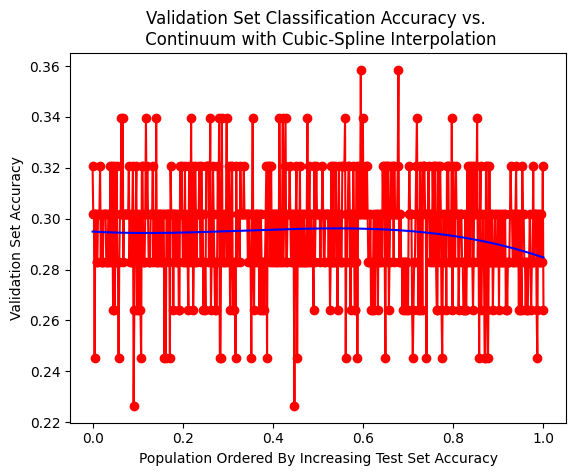

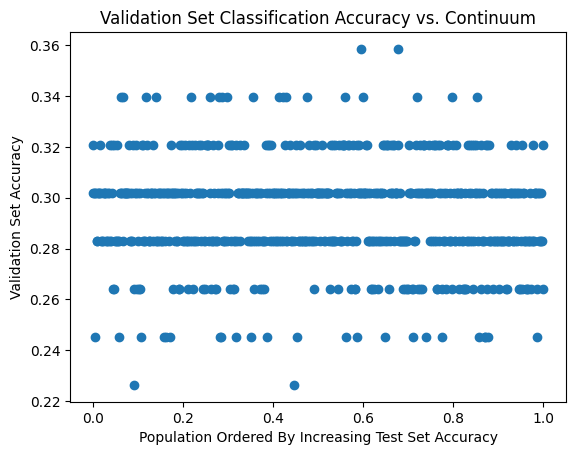

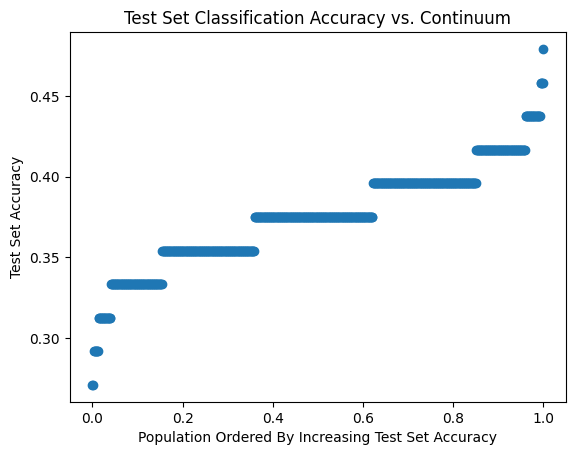

In [42]:
import importlib
importlib.reload(creator)
importlib.reload(base)
importlib.reload(tools)
importlib.reload(algorithms)
import matplotlib.pyplot as plt
if __name__ == '__main__':
    '''
    First, we will apply random forest using all the features to acquire a baseline accuracy.
    # '''
    individual = [1 for i in range(X_scaled.shape[1])]
    testAccuracy = getFitness(individual, X_train, X_test, y_train, y_test)
    validationAccuracy = getFitness(individual, X_trainAndTest, X_validation, y_trainAndTest, y_validation)
    print('\nTest accuracy with all features: \t' + str(testAccuracy[0]))
    print('Validation accuracy with all features: \t' + str(validationAccuracy[0]) + '\n')

    '''
    Now, we will apply a genetic algorithm to choose a subset of features that gives a better accuracy than the baseline.
    '''
    hof = getHof()
    print("Got hof")
    testAccuracyList, validationAccuracyList, individualList, percentileList = getMetrics(hof)

    # Get a list of subsets that performed best on validation data
    maxValAccSubsetIndicies = [index for index in range(len(validationAccuracyList)) if validationAccuracyList[index] == max(validationAccuracyList)]
    maxValIndividuals = [individualList[index] for index in maxValAccSubsetIndicies]
    maxValSubsets = [[list(X_df)[index] for index in range(len(individual)) if individual[index] == 1] for individual in maxValIndividuals]

    print('\n---Optimal Feature Subset(s)---\n')
    for index in range(len(maxValAccSubsetIndicies)):
        print('Percentile: \t\t\t' + str(percentileList[maxValAccSubsetIndicies[index]]))
        print('Validation Accuracy: \t\t' + str(validationAccuracyList[maxValAccSubsetIndicies[index]]))
        print('Individual: \t' + str(maxValIndividuals[index]))
        print('Number Features In Subset: \t' + str(len(maxValSubsets[index])))
        print('Feature Subset: ' + str(maxValSubsets[index]))

    '''
    Now, we plot the test and validation classification accuracy to see how these numbers change as we move from our worst feature subsets to the 
    best feature subsets found by the genetic algorithm.
    '''
    # Calculate best fit line for validation classification accuracy (non-linear)
    tck = interpolate.splrep(percentileList, validationAccuracyList, s=5.0)
    ynew = interpolate.splev(percentileList, tck)

    e = plt.figure(1)
    plt.plot(percentileList, validationAccuracyList, marker='o', color='r')
    plt.plot(percentileList, ynew, color='b')
    plt.title('Validation Set Classification Accuracy vs. \n Continuum with Cubic-Spline Interpolation')
    plt.xlabel('Population Ordered By Increasing Test Set Accuracy')
    plt.ylabel('Validation Set Accuracy')
    e.show()

    f = plt.figure(2)
    plt.scatter(percentileList, validationAccuracyList)
    plt.title('Validation Set Classification Accuracy vs. Continuum')
    plt.xlabel('Population Ordered By Increasing Test Set Accuracy')
    plt.ylabel('Validation Set Accuracy')
    f.show()

    g = plt.figure(3)
    plt.scatter(percentileList, testAccuracyList)
    plt.title('Test Set Classification Accuracy vs. Continuum')
    plt.xlabel('Population Ordered By Increasing Test Set Accuracy')
    plt.ylabel('Test Set Accuracy')
    g.show()

    # input()

In [92]:
X_gfp,y_gfp = np.load('all_labels_covert_gfp_no_pca.npz').values()

In [93]:
X_gfp.shape

(526, 154)

In [ ]:
toolbox.map(toolbox.evaluate, )

NameError: name 'hof' is not defined

In [ ]:
z = zip([1,2,3], [4,5,6])

In [30]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=14, out_channels=64, kernel_size=14, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, encoding_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [84]:
import torch
import torch.nn as nn
import numpy as np

class AutoEncoder(nn.Module):
    def __init__(self, input_dim: int, time_dim: int, encoding_dim: int):
        super(AutoEncoder, self).__init__()
        self.time_dim = time_dim
        self.L_conv = (self.time_dim - 5 + 2*0)//1 + 1
        self.conv1 = nn.Conv1d(in_channels=14, out_channels=64, kernel_size=7, stride=1, padding='same')
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding='same')
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=5, stride=1, padding='same')
        self.conv4 = nn.Conv1d(in_channels=256, out_channels=512, kernel_size=5, stride=1)
        self.fc1 = nn.Linear(512, encoding_dim)
        self.rev_fc1 = nn.Linear(encoding_dim, 512*self.L_conv)
        self.deconv1 = nn.ConvTranspose1d(in_channels=512, out_channels=256, kernel_size=5, stride=1, padding=0)
        self.deconv2 = nn.ConvTranspose1d(in_channels=256, out_channels=128, kernel_size=5, stride=1, padding=(5-1)//2)
        self.deconv3 = nn.ConvTranspose1d(in_channels=128, out_channels=64, kernel_size=5, stride=1, padding=(5-1)//2)
        self.deconv4 = nn.ConvTranspose1d(in_channels=64, out_channels=14, kernel_size=7, stride=1, padding=(7-1)//2)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
        self.encoder = nn.Sequential(
            self.conv1,
            nn.ReLU(),
            self.conv2,
            nn.ReLU(),
            self.conv3,
            nn.ReLU(),
            self.conv4,
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            self.fc1,
            
        )
        self.decoder = nn.Sequential(
            self.rev_fc1,
            nn.ReLU(),
            nn.Unflatten(1, (512, self.L_conv)),
            self.deconv1,
            nn.ReLU(),
            self.deconv2,
            nn.ReLU(),
            self.deconv3,
            nn.ReLU(),
            self.deconv4,
            nn.Sigmoid() 
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
# (nn.ReLU()(nn.Conv1d(in_channels=14, out_channels=64, kernel_size=14, stride=1)(torch.tensor(np.random.rand(14,130),dtype=torch.float32)))).shape

torch.Size([64, 117])

In [ ]:
# test_data = np.random.rand(1, 14, 130)
# test_data = torch.tensor(test_data, dtype=torch.float32)
# model = AutoEncoder(input_dim=14, encoding_dim=1024, time_dim=130)
# output = model(test_data)


In [ ]:
# torch.flatten(torch.tensor(np.random.rand(2,3,4))).shape

torch.Size([24])

In [85]:
X,y = np.load("unfiltered_covert_pca_all_labels.npz").values()

In [86]:
model = AutoEncoder(input_dim=X.shape[1], time_dim=X.shape[2], encoding_dim=1024)

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

device = torch.device('cpu')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1)).reshape(X_test.shape)
# X_train_scaled = X_train
# X_test_scaled = X_test
# X_train_scaled, y_train_scaled = augment_with_noise(X_train_scaled, y_train, n_augment=2, noise_level=0.05)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)
print(f"Using device: {device}")

X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

criterion = nn.SmoothL1Loss(beta=0.05)
optimizer = optim.Adam(model.parameters(), lr=0.05, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
test_dataset = TensorDataset(X_test_tensor, X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Using device: cpu


In [88]:
conv1_weights_over_time = []

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)       
        optimizer.zero_grad()      
        data_noise = torch.randn(inputs.shape).to(device)
        data_noise = inputs + data_noise
        outputs = model(data_noise)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()    
        # examine the weights of the first conv layer
        conv1_weights_over_time.append(model.conv1.weight.detach().cpu().numpy().copy())
        running_loss += loss.item() * inputs.size(0)
    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss



In [89]:
def test_epoch(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            inputs, target = data.to(device), target.to(device)   
            data_noise = torch.randn(inputs.shape).to(device)
            data_noise = inputs + data_noise
            output = model(data_noise)
            loss = criterion(output,target)
            running_loss += loss.item() * inputs.size(0)
    
    test_loss = running_loss / len(test_loader.dataset)   
    return test_loss

In [90]:
num_epochs = 2
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss = test_epoch(model, test_loader, criterion, device)

    scheduler.step()
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    if epoch % 1 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}'
            f'Test Loss: {test_loss:.4f}')

Epoch   0: Train Loss: 0.5537Test Loss: 0.5666
Epoch   1: Train Loss: 0.5518Test Loss: 0.5666


In [ ]:
# import pickle

# with open("processed_data_pca.pkl", "rb") as f:
#     data_everythin = pickle.load(f)

In [ ]:
# (data_everythin[0]["raw"].get_data()).shape

(14, 173221)

In [91]:
first_first_first = [conv1_weights_over_time[i][53,2,6] for i in range(len(conv1_weights_over_time))]

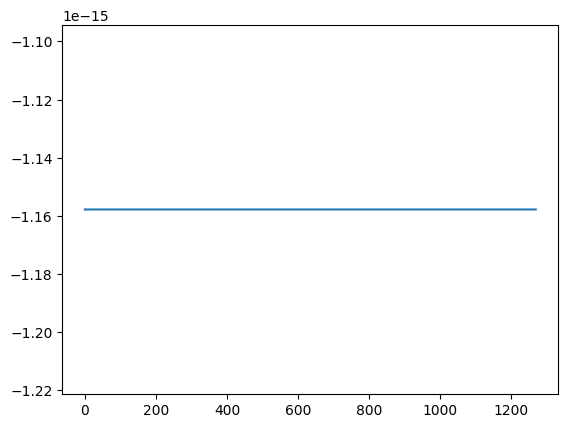

In [79]:
plt.plot(first_first_first)

In [94]:
np.sum(np.abs(conv1_weights_over_time[0])-np.abs(conv1_weights_over_time[-1]))

155.43173